# Latent ODE for irregularly-observed Inhomogeneous Poisson Processes

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/xtremax/blob/main/docs/notebooks/latent_ode_ipp.ipynb)

This notebook combines two ideas from the literature into one xtremax-flavoured example:

- The **Latent ODE** generative model of [Rubanova, Chen & Duvenaud (NeurIPS 2019), "Latent ODEs for Irregularly-Sampled Time Series"](https://arxiv.org/abs/1907.03907) — a VAE whose latent state evolves under a neural ODE, naturally accommodating irregularly-sampled data.
- xtremax's **Inhomogeneous Poisson Process** primitives (`ipp_log_prob`, `integrate_log_intensity`, `ipp_sample_thinning`).

The generative model is

$$z_0 \sim \mathcal{N}(0, I), \qquad \frac{dz}{dt} = f_\text{lat}(z, t), \qquad \log\lambda(t) = g_\theta(z(t)),$$

observed as event times $\{t_i\}$ from $\mathrm{IPP}(\lambda)$ on $[0, T]$.

Inference is amortised with a **pure neural-ODE encoder** in the spirit of [Kidger et al. (2020), "Neural CDEs"](https://arxiv.org/abs/2005.08926): the irregular event sequence is summarised by its counting process $N(t) = \#\{t_i \le t\}$, linearly interpolated to a continuous control signal, and fed into an encoder ODE

$$\frac{dh}{dt} = f_\text{enc}\big(h(t),\, \hat N(t),\, t\big),\qquad h(0) = 0.$$

The final state $h(T)$ is mapped to $(\mu, \log\sigma^2)$ of $q(z_0)$. **No RNN cells anywhere** — observations enter the encoder only through the counting-process path.

**Likelihood.** xtremax's `ipp_log_prob` evaluates the standard IPP log-likelihood

$$\log L = \sum_i \log\lambda(t_i) - \Lambda(T), \qquad \Lambda(T) = \int_0^T \lambda(s)\,ds,$$

given a callable for $\log\lambda$ at requested times and a pre-computed compensator. We build $\Lambda(T)$ with `integrate_log_intensity`.

In [1]:
from __future__ import annotations


%pip install -q xtremax diffrax interpax optax matplotlib  # uncomment on Colab
import diffrax
import equinox as eqx
import interpax
import jax
import jax.nn as jnn
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import optax

from xtremax.point_processes import integrate_log_intensity
from xtremax.point_processes.primitives import ipp_log_prob, ipp_sample_thinning


plt.rcParams.update(
    {
        "figure.dpi": 110,
        "figure.constrained_layout.use": True,
        "axes.grid": True,
        "grid.linewidth": 0.6,
        "grid.alpha": 0.5,
        "axes.titleweight": "semibold",
    }
)


def style_axes(ax, *, aspect=None):
    ax.minorticks_on()
    ax.grid(True, which="major", linewidth=0.8, alpha=0.5)
    ax.grid(True, which="minor", linewidth=0.4, alpha=0.25)
    if aspect is not None:
        ax.set_aspect(aspect)
    return ax


# Plain matplotlib palette (tab10), 10 entries; we only use a handful.
palette = [plt.cm.tab10(i) for i in range(10)]

/home/azureuser/localfiles/xtremax/.venv/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


/home/azureuser/localfiles/xtremax/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Synthetic IPP data

We draw 100 sequences from a sinusoidally-modulated rate

$$\lambda_i(t) = a_i \cdot \big(1 + \mathrm{amp}_i \sin(\omega t + \phi_i)\big), \qquad t \in [0, T].$$

Each sequence has its own random amplitude $\mathrm{amp}_i \in [0, 0.85]$, baseline $a_i \in [3, 7]$, and phase $\phi_i \in [0, 2\pi)$ — but a shared frequency $\omega$. The model has access only to event times and must recover the per-sequence intensity from those alone.

In [2]:
T_MAX = 10.0
OMEGA = 2.0 * jnp.pi / 4.0  # one full cycle every 4 time units
N_SEQ = 100
MAX_EVENTS = 80


def true_log_intensity(t, amp, base, phase):
    rate = base * (1.0 + amp * jnp.sin(OMEGA * t + phase))
    return jnp.log(jnp.clip(rate, a_min=1e-6))


def sample_one_sequence(key):
    k_amp, k_base, k_phase, k_thin = jr.split(key, 4)
    amp = jr.uniform(k_amp, minval=0.0, maxval=0.85)
    base = jr.uniform(k_base, minval=3.0, maxval=7.0)
    phase = jr.uniform(k_phase, minval=0.0, maxval=2.0 * jnp.pi)
    lambda_max = base * (1.0 + amp)

    def log_lam(times):
        return true_log_intensity(times, amp, base, phase)

    times, mask, _ = ipp_sample_thinning(
        k_thin,
        log_lam,
        T=T_MAX,
        lambda_max=lambda_max,
        max_candidates=MAX_EVENTS,
    )
    # Re-pack so accepted events come first in time order and padding fills
    # the tail. ipp_sample_thinning returns its buffer sorted by *candidate*
    # time, but thinning rejects some candidates mid-buffer, breaking
    # monotonicity once we want a clean (real_1 < … < real_n < T_MAX … T_MAX)
    # layout (which downstream code relies on for diffrax SaveAt(ts=…)).
    sort_key = jnp.where(mask, times, T_MAX + 1.0)
    order = jnp.argsort(sort_key)
    times = jnp.take(times, order)
    mask = jnp.take(mask, order)
    times = jnp.where(mask, times, T_MAX)
    params = jnp.stack([amp, base, phase])
    return times, mask, params


keys = jr.split(jr.PRNGKey(0), N_SEQ)
event_times, event_mask, true_params = jax.vmap(sample_one_sequence)(keys)
n_events_per = jnp.sum(event_mask, axis=-1)
print(f"sequences           : {N_SEQ}")
print(f"max-events buffer   : {MAX_EVENTS}")
print(f"mean events / seq   : {float(jnp.mean(n_events_per)):.1f}")
print(
    f"min/max events      : {int(jnp.min(n_events_per))} / {int(jnp.max(n_events_per))}"
)

sequences           : 100
max-events buffer   : 80
mean events / seq   : 47.0


min/max events      : 22 / 65


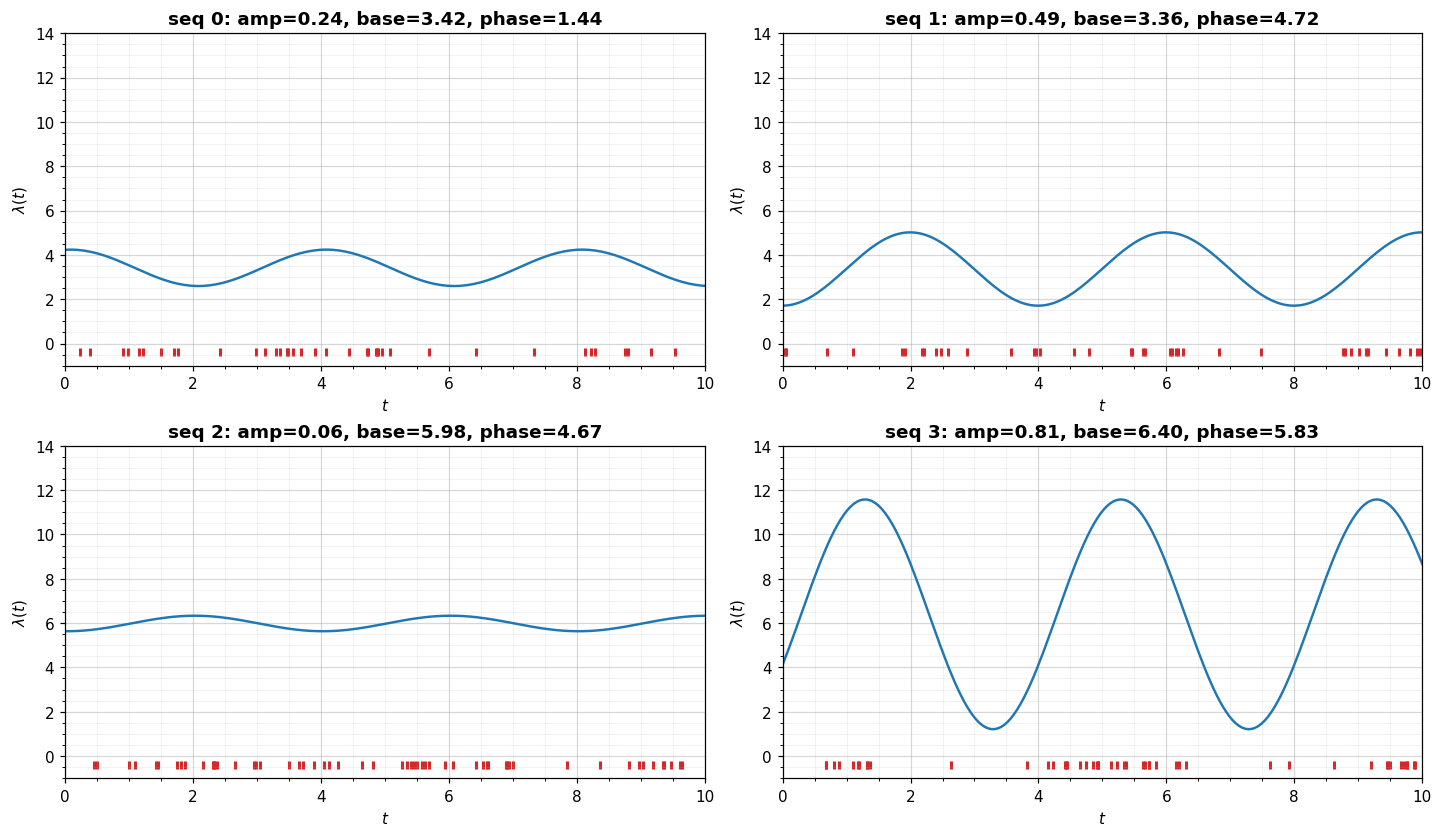

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7.5))
t_dense = jnp.linspace(0.0, T_MAX, 200)
for k, ax in enumerate(axes.flat):
    amp_k, base_k, phase_k = true_params[k]
    lam = jnp.exp(true_log_intensity(t_dense, amp_k, base_k, phase_k))
    ax.plot(np.asarray(t_dense), np.asarray(lam), color=palette[0], linewidth=1.6)
    times_k = np.asarray(event_times[k])[np.asarray(event_mask[k])]
    ax.scatter(
        times_k,
        np.full_like(times_k, -0.4),
        s=28,
        marker="|",
        color=palette[3],
        linewidths=2.0,
    )
    ax.set_xlim(0, T_MAX)
    ax.set_ylim(-1.0, 14.0)
    ax.set_title(
        f"seq {k}: amp={float(amp_k):.2f}, base={float(base_k):.2f}, phase={float(phase_k):.2f}"
    )
    ax.set_xlabel("$t$")
    ax.set_ylabel(r"$\lambda(t)$")
    style_axes(ax)
plt.show()

## 2. Encoder via the counting process

For each sequence we precompute $N(t) = \#\{t_i \le t\}$ on a dense reference grid, then linearly interpolate it to a continuous control signal $\hat N(t)$ for the encoder ODE. Two notes:

- The grid is shared across sequences (same shape under `vmap`), but each sequence has its own count values.
- Linear interpolation of a step function adds a small smoothing artifact; for a Latent ODE this is fine because the encoder integrates against $\hat N(t)$ rather than reading point values. To get the original Kidger et al. natural-cubic-spline behaviour, switch `method="linear"` to `method="cubic2"` below.

In [4]:
N_GRID_ENC = 60
t_grid_enc = jnp.linspace(0.0, T_MAX, N_GRID_ENC)


def counting_process_grid(times, mask):
    # times: (MAX_EVENTS,), mask: (MAX_EVENTS,), returns (N_GRID_ENC,)
    contrib = jnp.where(mask[:, None], (times[:, None] <= t_grid_enc[None, :]), 0)
    return jnp.sum(contrib, axis=0).astype(jnp.float32)


count_paths = jax.vmap(counting_process_grid)(event_times, event_mask)
print(f"count_paths shape       : {count_paths.shape}")
print(f"count_paths[0, ::10]    : {count_paths[0, ::10]}")

count_paths shape       : (100, 60)
count_paths[0, ::10]    : [ 0.  7. 14. 28. 30. 34.]


## 3. Model

Two MLP vector fields and a small log-rate decoder. The encoder vector field takes a concatenation of $(t, h, \hat N(t))$; the dynamics field takes $(t, z)$; the decoder maps $z \to \log\lambda$.

In [5]:
LATENT_DIM = 4
ENC_HIDDEN = 24
DEC_HIDDEN = 16
N_GRID_QUAD = 64
LAMBDA_FLOOR = 1e-3


def _interp_count(t_query, count_path):
    return interpax.interp1d(
        jnp.atleast_1d(t_query),
        t_grid_enc,
        count_path,
        method="linear",
        extrap=True,
    )[0]


class TimeStateMLP(eqx.Module):
    """``f(t, x)`` via concatenation, returning a vector of size ``out_dim``."""

    mlp: eqx.nn.MLP

    def __init__(self, key, *, in_dim, out_dim, hidden):
        self.mlp = eqx.nn.MLP(
            in_size=in_dim + 1,  # +1 for time
            out_size=out_dim,
            width_size=hidden,
            depth=2,
            activation=jnn.tanh,
            key=key,
        )

    def __call__(self, t, x, control=None):
        t_arr = jnp.reshape(jnp.asarray(t), (1,))
        if control is None:
            features = jnp.concatenate([t_arr, x])
        else:
            features = jnp.concatenate([t_arr, x, control])
        return self.mlp(features)

    @property
    def out_dim(self):
        return self.mlp.out_size


class LatentODE_IPP(eqx.Module):
    encoder_vf: TimeStateMLP
    enc_head: eqx.nn.Linear
    dynamics_vf: TimeStateMLP
    decoder: eqx.nn.MLP

    def __init__(self, key):
        k_enc, k_head, k_dyn, k_dec = jr.split(key, 4)
        self.encoder_vf = TimeStateMLP(
            k_enc, in_dim=ENC_HIDDEN + 1, out_dim=ENC_HIDDEN, hidden=32
        )  # +1 for the count-path control
        self.enc_head = eqx.nn.Linear(ENC_HIDDEN, 2 * LATENT_DIM, key=k_head)
        self.dynamics_vf = TimeStateMLP(
            k_dyn, in_dim=LATENT_DIM, out_dim=LATENT_DIM, hidden=32
        )
        self.decoder = eqx.nn.MLP(
            in_size=LATENT_DIM,
            out_size=1,
            width_size=DEC_HIDDEN,
            depth=2,
            activation=jnn.tanh,
            key=k_dec,
        )

    def encode(self, count_path):
        def vf(t, h, args):
            n_t = _interp_count(t, args)
            control = jnp.atleast_1d(n_t)
            return self.encoder_vf(t, h, control)

        sol = diffrax.diffeqsolve(
            diffrax.ODETerm(vf),
            solver=diffrax.Tsit5(),
            t0=0.0,
            t1=T_MAX,
            dt0=0.1,
            y0=jnp.zeros(ENC_HIDDEN),
            args=count_path,
            saveat=diffrax.SaveAt(t1=True),
            stepsize_controller=diffrax.PIDController(rtol=1e-3, atol=1e-4),
            adjoint=diffrax.RecursiveCheckpointAdjoint(),
            max_steps=4096,
        )
        h_final = sol.ys[-1]
        params = self.enc_head(h_final)
        mu, log_var = jnp.split(params, 2, axis=-1)
        log_var = jnp.clip(log_var, -8.0, 4.0)
        return mu, log_var

    def latent_trajectory(self, z0, t_eval):
        # Always integrate over the full window [0, T_MAX] so z(0) = z0 has
        # the right semantics; saveat lets us harvest the latent at any
        # subset of times in [0, T_MAX] (event times, quadrature grid, …).
        def vf(t, z, args):
            return self.dynamics_vf(t, z, None)

        sol = diffrax.diffeqsolve(
            diffrax.ODETerm(vf),
            solver=diffrax.Tsit5(),
            t0=0.0,
            t1=T_MAX,
            dt0=0.1,
            y0=z0,
            saveat=diffrax.SaveAt(ts=t_eval),
            stepsize_controller=diffrax.PIDController(rtol=1e-3, atol=1e-4),
            adjoint=diffrax.RecursiveCheckpointAdjoint(),
            max_steps=4096,
        )
        return sol.ys

    def log_intensity(self, z_traj):
        # z_traj: (T, LATENT_DIM) -> (T,)
        return jax.vmap(self.decoder)(z_traj)[..., 0]

    def elbo(self, key, count_path, evt_times, evt_mask, beta=1.0):
        mu, log_var = self.encode(count_path)
        eps = jr.normal(key, mu.shape)
        z0 = mu + jnp.exp(0.5 * log_var) * eps

        # We need log λ at (a) event times and (b) a quadrature grid.
        # Solve once over the union of times: prepend 0, append T to the
        # event-time buffer to get monotone bounds, then interpolate the
        # latent for the quadrature grid from a separate solve.
        z_at_events = self.latent_trajectory(z0, evt_times)
        log_lam_events = self.log_intensity(z_at_events)

        t_grid_q = jnp.linspace(0.0, T_MAX, N_GRID_QUAD)
        z_grid = self.latent_trajectory(z0, t_grid_q)
        log_lam_grid = self.log_intensity(z_grid)

        # Compensator Λ(T) via xtremax's quadrature primitive, threading
        # a closure that reads the precomputed grid.
        def log_lam_fn(query):
            return interpax.interp1d(
                jnp.atleast_1d(query),
                t_grid_q,
                log_lam_grid,
                method="linear",
                extrap=True,
            ).reshape(query.shape)

        Lambda_T = integrate_log_intensity(
            log_lam_fn, jnp.asarray(0.0), jnp.asarray(T_MAX), n_points=N_GRID_QUAD
        )

        # IPP log-likelihood via xtremax: padding rows are zeroed by mask.
        # Pass a closure that returns the precomputed log_lam_events; the
        # primitive evaluates it on `evt_times` and we have those values
        # already, so we just hand them back.
        def event_log_lam_fn(_times):
            return log_lam_events

        log_lik = ipp_log_prob(evt_times, evt_mask, event_log_lam_fn, Lambda_T)
        kl = 0.5 * jnp.sum(jnp.exp(log_var) + jnp.square(mu) - 1.0 - log_var)
        return log_lik - beta * kl, log_lik, kl


key = jr.key(0)
model_key, train_key, eval_key = jr.split(key, 3)
model = LatentODE_IPP(model_key)

n_params = sum(
    int(np.prod(p.shape))
    for p in jax.tree_util.tree_leaves(eqx.filter(model, eqx.is_array))
)
print(f"latent dim                : {LATENT_DIM}")
print(f"encoder hidden            : {ENC_HIDDEN}")
print(f"decoder hidden            : {DEC_HIDDEN}")
print(f"trainable parameters      : {n_params}")

latent dim                : 4
encoder hidden            : 24
decoder hidden            : 16
trainable parameters      : 4661


## 4. Training

Per gradient step: encode by integrating the encoder ODE forward against the count path; sample $z_0$ via reparameterisation; integrate the latent ODE on both event times and a quadrature grid; assemble the IPP log-likelihood and KL.

In [6]:
N_EPOCHS = 200
BATCH_SIZE = 25
LR = 5e-3


@eqx.filter_jit
def loss_fn(model, key, count_batch, evt_batch, mask_batch, beta):
    keys = jr.split(key, count_batch.shape[0])
    elbos, lls, kls = jax.vmap(model.elbo, in_axes=(0, 0, 0, 0, None))(
        keys, count_batch, evt_batch, mask_batch, beta
    )
    return -jnp.mean(elbos), (jnp.mean(lls), jnp.mean(kls))


@eqx.filter_jit
def step(model, opt_state, key, count_batch, evt_batch, mask_batch, beta):
    (loss, (ll, kl)), grads = eqx.filter_value_and_grad(loss_fn, has_aux=True)(
        model, key, count_batch, evt_batch, mask_batch, beta
    )
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss, ll, kl


optimizer = optax.chain(
    optax.clip_by_global_norm(5.0),
    optax.adam(LR),
)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

KL_WARMUP_EPOCHS = 80


def beta_schedule(epoch):
    # Linear warm-up of the KL weight from 0 -> 1 over the first
    # ``KL_WARMUP_EPOCHS`` epochs. With β = 0 the model can use z_0
    # freely without paying a KL cost — this avoids the standard VAE
    # posterior-collapse failure mode where the likelihood term is
    # easier to optimise by ignoring z_0 and predicting the marginal
    # mean intensity for every sequence.
    return min(1.0, epoch / max(1, KL_WARMUP_EPOCHS))


losses, lls, kls, betas = [], [], [], []
for epoch in range(N_EPOCHS):
    train_key, perm_key, batch_key = jr.split(train_key, 3)
    perm = jr.permutation(perm_key, N_SEQ)
    counts_shuf = count_paths[perm]
    times_shuf = event_times[perm]
    mask_shuf = event_mask[perm]
    beta = jnp.asarray(beta_schedule(epoch), dtype=jnp.float32)
    e_loss, e_ll, e_kl = 0.0, 0.0, 0.0
    n_batches = N_SEQ // BATCH_SIZE
    for b in range(n_batches):
        sl = slice(b * BATCH_SIZE, (b + 1) * BATCH_SIZE)
        batch_key, sub = jr.split(batch_key)
        model, opt_state, loss, ll, kl = step(
            model,
            opt_state,
            sub,
            counts_shuf[sl],
            times_shuf[sl],
            mask_shuf[sl],
            beta,
        )
        e_loss += float(loss)
        e_ll += float(ll)
        e_kl += float(kl)
    losses.append(e_loss / n_batches)
    lls.append(e_ll / n_batches)
    kls.append(e_kl / n_batches)
    betas.append(float(beta))
    if epoch == 0 or (epoch + 1) % 20 == 0:
        print(
            f"epoch {epoch + 1:>4d}  β {betas[-1]:.2f}  loss {losses[-1]:>9.3f}  "
            f"log_lik {lls[-1]:>9.3f}  KL {kls[-1]:>7.3f}"
        )

epoch    1  β 0.00  loss     5.405  log_lik    -5.405  KL  16.110


epoch   20  β 0.24  loss   -26.225  log_lik    26.625  KL   1.683


epoch   40  β 0.49  loss   -26.171  log_lik    26.691  KL   1.067


epoch   60  β 0.74  loss   -25.568  log_lik    26.092  KL   0.711


epoch   80  β 0.99  loss   -25.840  log_lik    26.325  KL   0.491


...

epoch  120  β 1.00  loss   -25.935  log_lik    26.242  KL   0.307


epoch  140  β 1.00  loss   -25.959  log_lik    26.330  KL   0.371


epoch  160  β 1.00  loss   -25.904  log_lik    26.266  KL   0.362


epoch  180  β 1.00  loss   -25.999  log_lik    26.459  KL   0.460


epoch  200  β 1.00  loss   -25.814  log_lik    26.197  KL   0.383


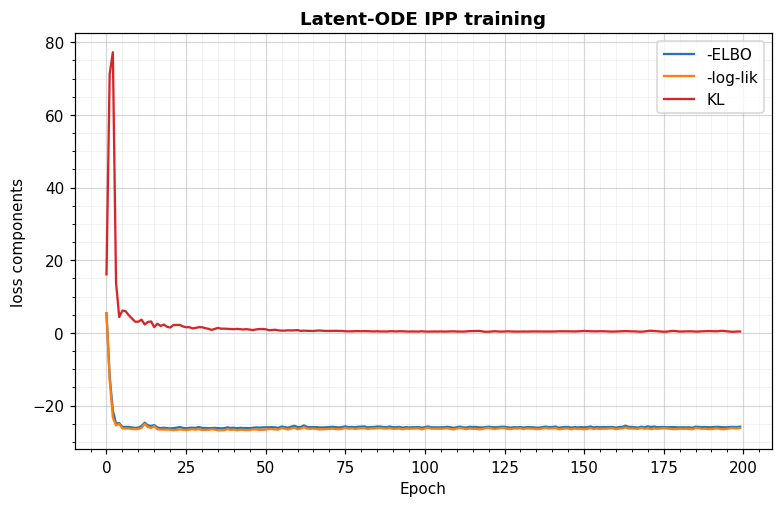

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ep = np.arange(len(losses))
ax.plot(ep, losses, color=palette[0], label="-ELBO")
ax.plot(ep, [-v for v in lls], color=palette[1], label="-log-lik")
ax.plot(ep, kls, color=palette[3], label="KL")
ax.set_xlabel("Epoch")
ax.set_ylabel("loss components")
ax.set_title("Latent-ODE IPP training")
ax.legend()
style_axes(ax)
plt.show()

## 5. Recovered intensities

For each held-out sequence we encode the events, use the **mean** of $q(z_0)$, decode on a dense grid, and overlay the recovered $\hat\lambda(t)$ on the ground-truth $\lambda(t)$ along with the event raster.

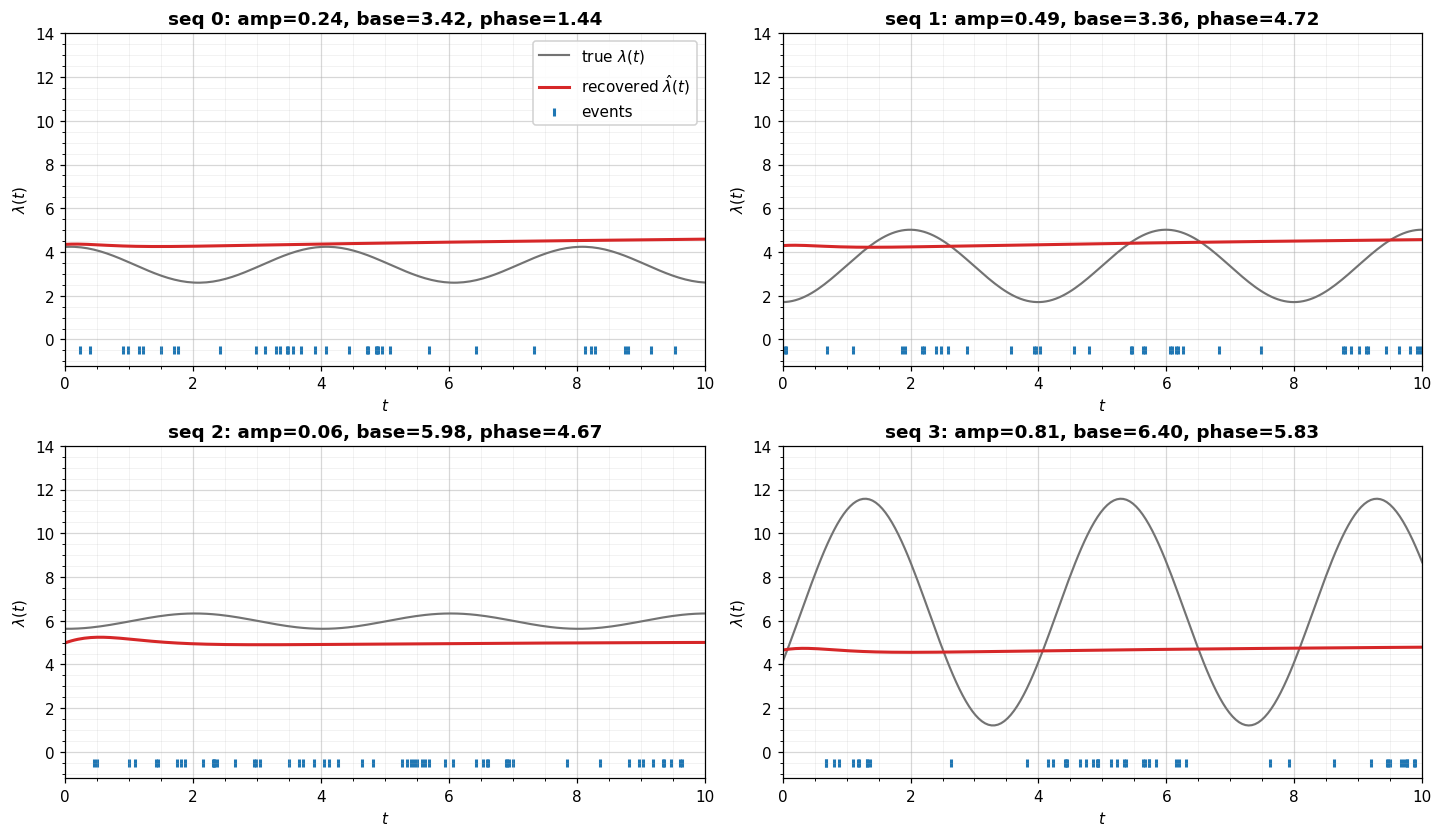

In [8]:
@eqx.filter_jit
def recover_intensity(model, count_path, t_target):
    mu, _ = model.encode(count_path)
    z0 = mu  # posterior mean — clean visualisation
    z_traj = model.latent_trajectory(z0, t_target)
    return jnp.exp(model.log_intensity(z_traj))


fig, axes = plt.subplots(2, 2, figsize=(13, 7.5))
for k, ax in enumerate(axes.flat):
    amp_k, base_k, phase_k = true_params[k]
    lam_true = jnp.exp(true_log_intensity(t_dense, amp_k, base_k, phase_k))
    lam_hat = recover_intensity(model, count_paths[k], t_dense)
    ax.plot(
        np.asarray(t_dense),
        np.asarray(lam_true),
        color="0.45",
        linewidth=1.4,
        label=r"true $\lambda(t)$",
    )
    ax.plot(
        np.asarray(t_dense),
        np.asarray(lam_hat),
        color=palette[3],
        linewidth=2.0,
        label=r"recovered $\hat\lambda(t)$",
    )
    times_k = np.asarray(event_times[k])[np.asarray(event_mask[k])]
    ax.scatter(
        times_k,
        np.full_like(times_k, -0.5),
        s=28,
        marker="|",
        color=palette[0],
        linewidths=2.0,
        label="events",
    )
    ax.set_xlim(0, T_MAX)
    ax.set_ylim(-1.2, 14.0)
    ax.set_title(
        f"seq {k}: amp={float(amp_k):.2f}, base={float(base_k):.2f}, phase={float(phase_k):.2f}"
    )
    ax.set_xlabel("$t$")
    ax.set_ylabel(r"$\lambda(t)$")
    style_axes(ax)
    if k == 0:
        ax.legend(loc="upper right", fontsize=10, framealpha=0.9)
plt.show()

## 6. Compensator residuals (time-rescaling diagnostic)

For an IPP, $\Lambda(t_i)$ on the recovered intensity should look like the event times of a **homogeneous Poisson process with rate 1**. Plotting cumulative event counts vs. $\Lambda(t)$ should yield a straight diagonal — a classical goodness-of-fit check for point-process intensities.

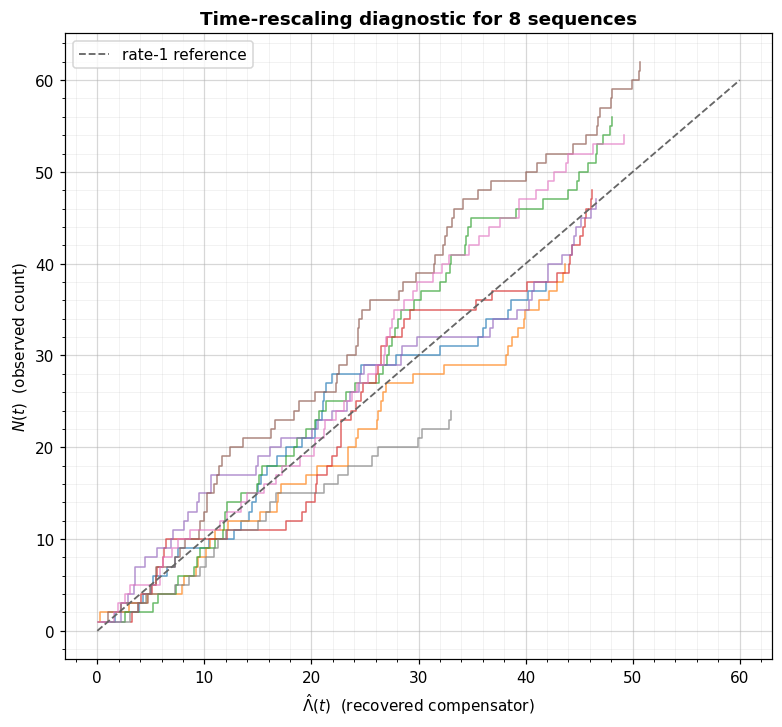

In [9]:
def cumulative_compensator(model, count_path, t_grid_q):
    mu, _ = model.encode(count_path)
    z_grid = model.latent_trajectory(mu, t_grid_q)
    log_lam_grid = model.log_intensity(z_grid)
    lam_grid = jnp.exp(log_lam_grid)
    # Cumulative trapezoid of λ̂ over the grid.
    dt = jnp.diff(t_grid_q)
    avg = 0.5 * (lam_grid[1:] + lam_grid[:-1])
    cum = jnp.concatenate([jnp.zeros(1), jnp.cumsum(avg * dt)])
    return cum


fig, ax = plt.subplots(figsize=(7, 6.5))
t_grid_q = jnp.linspace(0.0, T_MAX, 256)
n_show = 8
for k in range(n_show):
    cum = cumulative_compensator(model, count_paths[k], t_grid_q)
    cum_at_events = jnp.interp(event_times[k], t_grid_q, cum)
    times_real = cum_at_events[event_mask[k]]
    times_real_sorted = jnp.sort(times_real)
    counts = jnp.arange(1, len(times_real_sorted) + 1)
    ax.step(
        np.asarray(times_real_sorted),
        np.asarray(counts),
        where="post",
        color=palette[k % len(palette)],
        alpha=0.7,
        linewidth=1.0,
    )

ax.plot(
    [0, 60],
    [0, 60],
    color="0.4",
    linestyle="--",
    linewidth=1.2,
    label="rate-1 reference",
)
ax.set_xlabel(r"$\hat\Lambda(t)$  (recovered compensator)")
ax.set_ylabel(r"$N(t)$  (observed count)")
ax.set_title("Time-rescaling diagnostic for 8 sequences")
ax.legend()
style_axes(ax)
plt.show()

## 7. Notes

- **Why a count-path encoder?** The original Latent ODE encoder is an ODE-RNN run backwards over the observation times. Replacing it with a pure neural ODE on $\hat N(t)$ (Kidger-style) keeps the model uniformly continuous-time — and for a point process, the cumulative count is the natural sufficient statistic the encoder should ingest.
- **Two ODE solves per sequence per gradient step.** Encoder forward (drives $h$) plus latent ODE forward (drives $z$, evaluated at both event times and a quadrature grid). The dominant cost is the latent solve because we save at $|\text{events}| + N_\text{quad}$ time points.
- **Why xtremax primitives?** `ipp_log_prob` is the canonical IPP likelihood with mask-aware padding, and `integrate_log_intensity` is the matching trapezoidal compensator. Plugging neural intensities into them keeps the math identical to the analytic IPP examples in the rest of the docs.
- **Time-rescaling.** When the model fits well, $\hat\Lambda(t_i)$ behaves like the arrival times of a unit-rate HPP, so the cumulative count is a near-diagonal staircase. Persistent deviation from the diagonal signals model misspecification (e.g., latent dynamics too rigid to capture per-sequence intensity shapes).